# Replicating Masquelier et al. (2008) with SuperNeuroABM

## STDP-Based Spatiotemporal Pattern Detection

### What is SuperNeuroABM?

SuperNeuroABM is a GPU-accelerated spiking neural network (SNN) simulation framework built on top of [SAGESim](https://github.com/ORNL/sagesim) (Scalable Agent-based GPU-Enabled Simulation). It models neurons and synapses as autonomous **agents**, each with its own internal state and customizable dynamics implemented as CUDA kernels.

**Core concepts:**

| Concept | Description |
|---------|-------------|
| **Soma** | A neuron agent with membrane dynamics (LIF, Izhikevich, HG-LIF, etc.) |
| **Synapse** | A connection agent between somas, with its own current dynamics |
| **Learning Rule** | A custom CUDA kernel (e.g., STDP) that modifies synaptic weights each tick |
| **YAML Config** | Defines hyperparameters, initial states, and learning parameters for all components |

**Typical workflow:**
1. Create a `NeuromorphicModel` with a YAML config
2. Register any custom learning rules
3. Create somas and synapses (referencing named configs)
4. Compile with `model.setup()`
5. Deliver input spikes and call `model.simulate()`
6. Retrieve results (spike times, weights, internal states)

In this tutorial, we use SuperNeuroABM to replicate a classic result in computational neuroscience.

## The Masquelier et al. (2008) Experiment

[Masquelier, Guyonneau, and Thorpe (2008)](https://doi.org/10.1162/neco.2008.12-06-420) demonstrated that a **single neuron** equipped with spike-timing-dependent plasticity (STDP) can learn to detect a recurring spatiotemporal spike pattern hidden in noisy Poisson background activity.

### Network Architecture

```
  Afferent 0    ──[synapse w/ STDP]──┐
  Afferent 1    ──[synapse w/ STDP]──┤
      ...                            ├──► Output Neuron (HG-LIF)
  Afferent 1999 ──[synapse w/ STDP]──┘
```

- **2000 input afferents** generate Poisson spike trains with time-varying rates (0–90 Hz)
- A fixed **50 ms spike pattern** is carried by the first 1000 afferents, embedded in ~12.5% of time slots
- **1 output neuron** receives all 2000 inputs through plastic synapses
- **Restricted nearest-neighbor STDP** modifies synaptic weights at each tick

### Expected Results

After ~100 s of simulated time:
- Weights for **pattern-carrying afferents increase**; others decrease
- The output neuron fires **selectively within ~10 ms** of pattern onset
- **Hit rate > 80%**; false alarm rate drops to **~0 Hz**

This demonstrates that STDP alone is sufficient for unsupervised temporal pattern learning.

## Step 1: Imports and Setup

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# -- Path setup (adjust if your directory layout differs) --
PROJECT_ROOT = Path("..").resolve()
EXPERIMENT_DIR = PROJECT_ROOT / "examples" / "masquelier_2008"

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(EXPERIMENT_DIR))

from superneuroabm.model import NeuromorphicModel
from exp_pair_wise_stdp_bounded_nn import exp_pair_wise_stdp_bounded_nn
from experiment_utils import (
    N_AFFERENTS, N_PATTERN, PATTERN_DURATION as PATTERN_DURATION_1MS,
    TOTAL_SECONDS, SEGMENT_SECONDS,
    DT as DT_CREATE, SEED,
    generate_rate_profiles, generate_poisson_spikes,
    generate_pattern, embed_pattern, tile_spike_trains,
)

print(f"N_AFFERENTS = {N_AFFERENTS}")
print(f"N_PATTERN   = {N_PATTERN}")
print(f"PATTERN     = {PATTERN_DURATION_1MS} ms")
print(f"TOTAL_TIME  = {TOTAL_SECONDS} s")

N_AFFERENTS = 2000
N_PATTERN   = 1000
PATTERN     = 50 ms
TOTAL_TIME  = 100 s


## Step 2: Model Configuration

SuperNeuroABM uses **YAML configuration files** to define hyperparameters for every component. The file is organized into three sections: `soma`, `synapse`, and `learning_rule`. Each section maps a **breed** (model type) to one or more **named configurations**.

```yaml
soma:
  hg_lif_soma:                          # breed name
    masquelier_hg_config_0:             # config name
      hyperparameters:
        T: 500.0                        # firing threshold
        taum: 10e-3                     # membrane time constant
        ...
      internal_state:
        u: 0.0                          # initial membrane potential
        ...

synapse:
  single_exp_synapse:
    masquelier_config_0:
      hyperparameters:
        weight: 0.475                   # initial synaptic weight
        tau_fall: 2.5e-3                # synaptic decay constant
        ...

learning_rule:
  exp_pair_wise_stdp_bounded:
    masquelier_default:
      learning_hyperparameters:
        tau_pre_stdp: 16.8e-3           # LTP trace time constant
        tau_post_stdp: 33.7e-3          # LTD trace time constant
        a_exp_pre: 0.03125              # LTP magnitude
        a_exp_post: 0.0265625           # LTD magnitude
        wmin: 0.0
        wmax: 1.0
```

When creating somas or synapses, you reference these by breed and config name. Let's look at the full config file used in this experiment:

In [2]:
with open(EXPERIMENT_DIR / "masquelier_config.yaml") as f:
    print(f.read())

soma:
  lif_soma:
    masquelier_config_0:
      hyperparameters:
        C: 1e-3                       # Membrane capacitance
        R: 10.0                       # Membrane resistance (tau_m = R*C = 10ms)
        vthr: 1163.48                 # Calibrated for ~63Hz initial firing rate
        tref: 1e-3                    # 1ms refractory period (paper)
        vrest: 0.0                    # Resting potential
        vreset: -50.0                 # Reset below rest (approximate afterhyperpolarization)
        tref_allows_integration: 0    # No integration during refractory period
        I_in: 0                       # No external current
        scaling_factor: 1.0           # No scaling
      internal_state:
        v: 0.0                        # Initial membrane voltage at rest
        tcount: 0.0                   # Time counter
        tlast: 0.0                    # Last spike time

  srm_soma:
    masquelier_srm_config_0:
      hyperparameters:
        theta: 731.21        

## Step 3: Create the Model

Building a SuperNeuroABM model starts with three steps:

1. **Instantiate** `NeuromorphicModel`, passing the YAML config file
2. **Register** any custom learning rules (each gets a numeric ID)
3. **Set global properties** like the simulation time step `dt`

### About `enable_internal_state_tracking`

When creating the model, the `enable_internal_state_tracking` flag controls whether the GPU records the **full time-series history** of every agent's internal state variables (membrane potential, synaptic currents, STDP traces, etc.) at every simulation tick. When enabled, you can call `model.get_internal_states_history(agent_id)` after simulation to retrieve a `(n_ticks, n_state_vars)` array — essential for plotting membrane potential traces or debugging dynamics.

However, this allocates a GPU buffer of shape `(n_agents x n_ticks x n_state_vars)`. For this experiment with 2001 agents and 1,000,000 ticks, that would consume several gigabytes of GPU memory. So we set it to **`False`** during the main learning simulation. Output spike times are always recorded regardless of this setting.

Later, to visualize the membrane potential (Figure 9), we create a **separate short-lived model** with tracking enabled and replay just 1 second of input at a time — keeping memory usage small while still getting full-resolution traces.

In [3]:
# -- Simulation time step: 0.1 ms (matches Brian2 defaultclock.dt) --
DT_SIM = 1e-4
TICK_SCALE = int(DT_CREATE / DT_SIM)        # 10x (1 ms spikes -> 0.1 ms ticks)
TOTAL_TICKS = int(TOTAL_SECONDS / DT_SIM)
PATTERN_DURATION = PATTERN_DURATION_1MS * TICK_SCALE  # 50 ms -> 500 ticks

# 1. Create the model
model = NeuromorphicModel(
    user_config=EXPERIMENT_DIR / "masquelier_config.yaml",
    enable_internal_state_tracking=False,  # saves GPU memory for long simulations
)

# 2. Register our custom STDP learning rule kernel
stdp_id = model.register_learning_rule(
    exp_pair_wise_stdp_bounded_nn,                    # the CUDA kernel function
    EXPERIMENT_DIR / "exp_pair_wise_stdp_bounded_nn.py",  # its source file
)

# 3. Set the simulation time step
model.set_global_property_value("dt", DT_SIM)

print(f"Model created with dt = {DT_SIM*1e6:.0f} us")
print(f"Registered STDP rule ID: {stdp_id}")
print(f"Total simulation: {TOTAL_SECONDS} s = {TOTAL_TICKS:,} ticks")

Model created with dt = 100 us
Registered STDP rule ID: 4
Total simulation: 100 s = 1,000,000 ticks


## Step 4: Build the Network

### 4a. Create the Output Neuron (Soma)

We create a single output neuron using `model.create_soma()`. The arguments reference the YAML config:

- `breed` selects the neuron model type (e.g., `"hg_lif_soma"` for the Hathway–Goodman LIF)
- `config_name` selects a named parameter set from the YAML file

In [4]:
soma = model.create_soma(
    breed="hg_lif_soma",                   # neuron model type
    config_name="masquelier_hg_config_0",  # parameter set from YAML
)

print(f"Output neuron created (agent ID: {soma})")

Output neuron created (agent ID: 0)


### 4b. Create Input Synapses with STDP Learning

Each afferent connects to the output neuron through a synapse agent. Key arguments to `model.create_synapse()`:

| Argument | Purpose |
|----------|---------|
| `breed` | Synapse model type (e.g., `"single_exp_synapse"`) |
| `pre_soma_id` | Presynaptic neuron ID; use **-1** for external input |
| `post_soma_id` | Postsynaptic neuron ID |
| `config_name` | Parameter set from YAML |
| `learning_rule` | Name of the learning rule breed |
| `learning_rule_config` | Named parameter set for the learning rule |
| `overrides` | Dict to override specific config values at creation time |

The `overrides` parameter is useful when you need to set a value that is only known at runtime — here, the `stdp_type` field is set to the ID returned by `register_learning_rule()`.

In [5]:
synapses = []
for i in range(N_AFFERENTS):
    syn = model.create_synapse(
        breed="single_exp_synapse",
        pre_soma_id=-1,                  # external input (no presynaptic soma)
        post_soma_id=soma,               # connected to our output neuron
        config_name="masquelier_config_0",
        learning_rule="exp_pair_wise_stdp_bounded",
        learning_rule_config="masquelier_default",
        overrides={"learning_hyperparameters": {"stdp_type": float(stdp_id)}},
    )
    synapses.append(syn)

print(f"Created {len(synapses)} synapses (IDs {synapses[0]}..{synapses[-1]})")

Created 2000 synapses (IDs 1..2000)


### 4c. Compile the Model

`model.setup()` performs one-time initialization: GPU code generation, JIT compilation, and data transfer to device memory. This must be called **once** before simulation.

In [6]:
model.setup(use_gpu=True)
print("Model compiled and ready for simulation.")

Model compiled and ready for simulation.


## Step 5: Generate Input Spike Trains

We generate Poisson spike trains with time-varying firing rates, then embed a fixed 50 ms pattern in the first 1000 afferents. The spike generation follows the original paper — what matters for SuperNeuroABM is that we end up with a **list of sorted spike-tick arrays**, one per afferent.

In [7]:
print("Generating input spike trains...")
t0 = time.time()

rng = np.random.default_rng(SEED)
segment_ticks_1ms = int(SEGMENT_SECONDS / DT_CREATE)

# Generate Poisson background spikes
SUB_SEG = 30000
spike_trains = [np.array([], dtype=np.int64) for _ in range(N_AFFERENTS)]
for sub_start in range(0, segment_ticks_1ms, SUB_SEG):
    sub_end = min(sub_start + SUB_SEG, segment_ticks_1ms)
    rates_sub = generate_rate_profiles(N_AFFERENTS, sub_end - sub_start, rng)
    trains_sub = generate_poisson_spikes(rates_sub, rng)
    for i in range(N_AFFERENTS):
        spike_trains[i] = np.concatenate([spike_trains[i], trains_sub[i] + sub_start])
    del rates_sub, trains_sub

# Generate and embed the fixed pattern
pattern_rng = np.random.default_rng(SEED + 1000)
pattern_spikes = generate_pattern(N_PATTERN, PATTERN_DURATION_1MS, pattern_rng)
embed_rng = np.random.default_rng(SEED + 2000)
spike_trains, pattern_onsets_1ms = embed_pattern(
    spike_trains, pattern_spikes, segment_ticks_1ms, embed_rng
)

# Tile to full duration
n_copies = TOTAL_SECONDS // SEGMENT_SECONDS
spike_trains = tile_spike_trains(spike_trains, segment_ticks_1ms, n_copies)
pattern_onsets = np.concatenate([
    pattern_onsets_1ms + i * segment_ticks_1ms for i in range(n_copies)
]) * TICK_SCALE

# Scale from 1 ms to 0.1 ms ticks
for i in range(N_AFFERENTS):
    spike_trains[i] = spike_trains[i] * TICK_SCALE

print(f"Done in {time.time() - t0:.1f}s")
print(f"  {N_AFFERENTS} afferents, ~{np.mean([len(t) for t in spike_trains]):.0f} spikes each")
print(f"  {len(pattern_onsets)} pattern presentations in {TOTAL_SECONDS}s")

Generating input spike trains...


Done in 4.3s
  2000 afferents, ~6063 spikes each
  250 pattern presentations in 100s


## Step 6: Run the Simulation

To run the experiment we:
1. **Load input spikes** into each synapse using `model.add_spike_list(synapse_id, spike_list)`, where each entry is a `[tick, value]` pair
2. **Call `model.simulate()`** to advance the network
3. **Retrieve output spikes** with `model.get_spike_times()`
4. **Read learned weights** from `model.get_agent_property_value(id, "hyperparameters")[0]`

The `simulate()` helper below wraps these steps into a single call.

In [8]:
def simulate(model, soma_id, synapse_ids, spike_trains, total_ticks, dt,
             chunk_seconds=10.0):
    """
    Run a full simulation with input spike delivery and result collection.

    Parameters
    ----------
    model : NeuromorphicModel
        Compiled model (after setup()).
    soma_id : int
        Agent ID of the output neuron.
    synapse_ids : list[int]
        Agent IDs of all input synapses.
    spike_trains : list[np.ndarray]
        Sorted spike-tick arrays, one per synapse.
    total_ticks : int
        Total number of simulation ticks.
    dt : float
        Simulation time step (seconds).
    chunk_seconds : float
        Processing window size (seconds).

    Returns
    -------
    spike_times : np.ndarray
        Tick indices when the output neuron fired.
    weight_snapshots : list[(float, np.ndarray)]
        (time_in_seconds, weight_array) snapshots.
    """
    chunk_ticks = int(chunk_seconds / dt)
    all_spike_times = []
    weight_snapshots = []

    for chunk_start in range(0, total_ticks, chunk_ticks):
        chunk_end = min(chunk_start + chunk_ticks, total_ticks)
        chunk_len = chunk_end - chunk_start

        # Deliver input spikes to each synapse
        for i, syn_id in enumerate(synapse_ids):
            lo = np.searchsorted(spike_trains[i], chunk_start, side="left")
            hi = np.searchsorted(spike_trains[i], chunk_end, side="left")
            spikes = spike_trains[i][lo:hi]
            if len(spikes) > 0:
                spike_list = [[int(t) - chunk_start, 1.0] for t in spikes]
                model.add_spike_list(synapse_id=syn_id, spike_list=spike_list)

        model.simulate(ticks=chunk_len, update_data_ticks=1)

        # Collect output spikes
        spikes_out = model.get_spike_times(soma_id)
        all_spike_times.extend(t + chunk_start for t in spikes_out)

        # Snapshot current weights (weight is hyperparameters[0])
        weights = np.array([
            model.get_agent_property_value(
                id=s, property_name="hyperparameters"
            )[0]
            for s in synapse_ids
        ], dtype=np.float32)
        weight_snapshots.append((chunk_end * dt, weights))

        model.reset(retain_parameters=True)

        print(f"  t = {chunk_end * dt:6.0f}s / {total_ticks * dt:.0f}s  "
              f"\u2014 output spikes so far: {len(all_spike_times)}")

    return np.array(all_spike_times, dtype=np.int64), weight_snapshots

In [9]:
print("Starting simulation...")
t_start = time.time()

spike_times, weight_snapshots = simulate(
    model, soma, synapses, spike_trains,
    total_ticks=TOTAL_TICKS,
    dt=DT_SIM,
)

elapsed = time.time() - t_start
print(f"\nSimulation complete: {len(spike_times)} output spikes in {elapsed:.1f}s")

Starting simulation...
  t =     10s / 100s  — output spikes so far: 436
  t =     20s / 100s  — output spikes so far: 460
  t =     30s / 100s  — output spikes so far: 488
  t =     40s / 100s  — output spikes so far: 509
  t =     50s / 100s  — output spikes so far: 539
  t =     60s / 100s  — output spikes so far: 575
  t =     70s / 100s  — output spikes so far: 599
  t =     80s / 100s  — output spikes so far: 617
  t =     90s / 100s  — output spikes so far: 646
  t =    100s / 100s  — output spikes so far: 672

Simulation complete: 672 output spikes in 285.2s


## Step 7: Analyze Results

We evaluate two metrics from the paper:
- **Hit rate**: fraction of pattern presentations that elicit a spike within 10 ms of onset
- **False alarm rate**: spikes per second outside any pattern window

In [10]:
# Convert ticks to seconds
spike_times_s = spike_times * DT_SIM
pattern_onsets_s = pattern_onsets * DT_SIM

# Hit rate: spike within 10 ms of pattern onset
hits = 0
latencies = []

for onset in pattern_onsets_s:
    window_end = onset + PATTERN_DURATION * DT_SIM
    lo = np.searchsorted(spike_times_s, onset, side="left")
    hi = np.searchsorted(spike_times_s, window_end, side="left")
    if hi > lo:
        lat_ms = (spike_times_s[lo] - onset) * 1000
        latencies.append(lat_ms)
        if lat_ms <= 10.0:
            hits += 1
    else:
        latencies.append(np.nan)

hit_rate = hits / len(pattern_onsets_s) * 100

# False alarm rate
spike_slots = spike_times // PATTERN_DURATION
in_pattern = np.isin(spike_slots, pattern_onsets // PATTERN_DURATION)
n_false = np.sum(~in_pattern)
non_pattern_s = TOTAL_SECONDS - len(pattern_onsets_s) * PATTERN_DURATION * DT_SIM
false_alarm_rate = n_false / non_pattern_s if non_pattern_s > 0 else 0

print(f"Hit rate:         {hit_rate:.1f}%")
print(f"False alarm rate: {false_alarm_rate:.2f} Hz")

Hit rate:         95.6%
False alarm rate: 4.58 Hz


### Weight Evolution

As STDP strengthens connections from pattern-carrying afferents and weakens the rest, the mean weight of the two groups diverges over time.

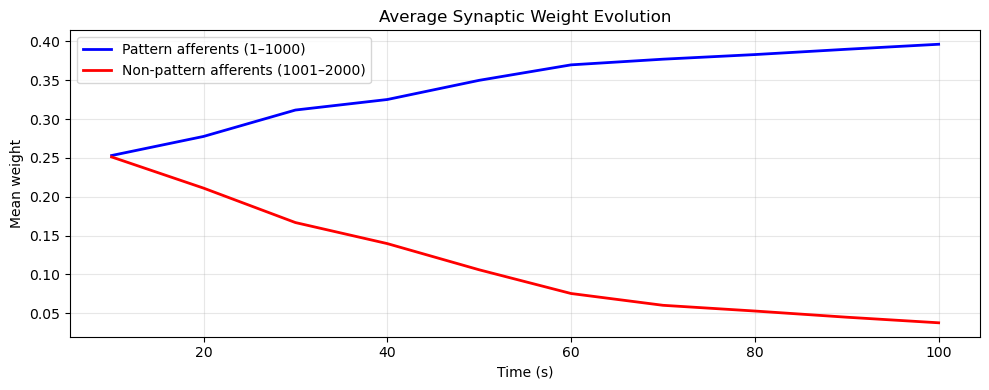

In [11]:
times = [t for t, _ in weight_snapshots]
pattern_w = [w[:N_PATTERN].mean() for _, w in weight_snapshots]
noise_w = [w[N_PATTERN:].mean() for _, w in weight_snapshots]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, pattern_w, "b-", lw=2, label="Pattern afferents (1\u20131000)")
ax.plot(times, noise_w, "r-", lw=2, label="Non-pattern afferents (1001\u20132000)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Mean weight")
ax.set_title("Average Synaptic Weight Evolution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Spike Latency

Over time, the output neuron's response to the pattern becomes faster and more precise, eventually firing within a few milliseconds of pattern onset.

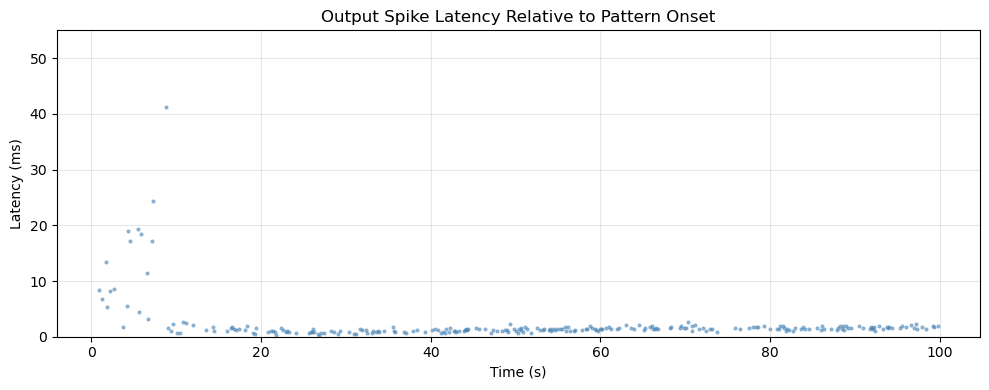

In [12]:
latencies_arr = np.array(latencies)
valid = ~np.isnan(latencies_arr)
onset_valid = pattern_onsets_s[valid]
lat_valid = latencies_arr[valid]

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(onset_valid, lat_valid, s=4, alpha=0.5, c="steelblue")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Latency (ms)")
ax.set_title("Output Spike Latency Relative to Pattern Onset")
ax.set_ylim(0, 55)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Final Weight Distribution

After learning, weights should be bimodal: pattern afferents near the upper bound and non-pattern afferents near the lower bound.

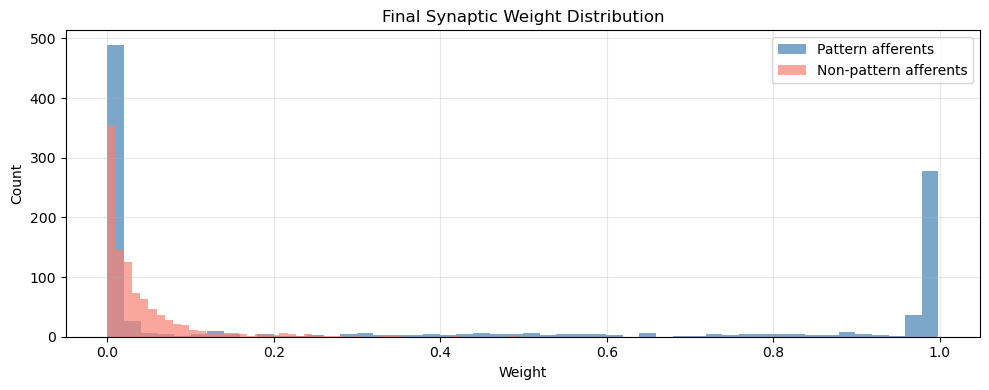

In [13]:
final_weights = weight_snapshots[-1][1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(final_weights[:N_PATTERN], bins=50, alpha=0.7,
        label="Pattern afferents", color="steelblue")
ax.hist(final_weights[N_PATTERN:], bins=50, alpha=0.7,
        label="Non-pattern afferents", color="salmon")
ax.set_xlabel("Weight")
ax.set_ylabel("Count")
ax.set_title("Final Synaptic Weight Distribution")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Membrane Potential Traces (Figure 9)

To visualize how the neuron's response evolves during learning, we record the membrane potential at three time windows: **early** (before learning), **mid** (around the time the neuron first reliably detects the pattern), and **late** (after convergence).

As discussed in Step 3, the main simulation ran with `enable_internal_state_tracking=False` to save GPU memory. To get the membrane potential, we create a **fresh model** with `enable_internal_state_tracking=True`, load the learned weights from our snapshots, and simulate just 1 second of input. This lets us call `model.get_internal_states_history(soma_id)` to retrieve the full voltage trace for that window.

Green shaded regions in the plots mark pattern presentation windows.

In [14]:
def record_potential(spike_trains, weight_snapshots, start_s, duration_s=1.0):
    """
    Record membrane potential for a time window using learned weights.

    Creates a fresh model with internal state tracking enabled,
    loads the appropriate learned weights, and simulates the window.

    Parameters
    ----------
    spike_trains : list[np.ndarray]
        Full spike trains (same as used for the main simulation).
    weight_snapshots : list[(float, np.ndarray)]
        Weight snapshots from the main simulation.
    start_s : float
        Start time of the recording window (seconds).
    duration_s : float
        Duration of the recording window (seconds).

    Returns
    -------
    t_arr : np.ndarray
        Time array in seconds.
    v_trace : np.ndarray
        Membrane potential trace.
    """
    start_tick = int(start_s / DT_SIM)
    end_tick = int((start_s + duration_s) / DT_SIM)
    n_ticks = end_tick - start_tick

    # Find the closest prior weight snapshot
    snap_times_s = [t for t, _ in weight_snapshots]
    snap_idx = np.searchsorted(snap_times_s, start_s, side="right") - 1
    if snap_idx < 0:
        weights = np.full(N_AFFERENTS, 0.475, dtype=np.float32)
    else:
        weights = weight_snapshots[snap_idx][1]

    # Create a fresh model with state tracking enabled
    rec_model = NeuromorphicModel(
        user_config=EXPERIMENT_DIR / "masquelier_config.yaml",
        enable_internal_state_tracking=True,
    )
    rec_model.set_global_property_value("dt", DT_SIM)

    rec_soma = rec_model.create_soma(
        breed="hg_lif_soma",
        config_name="masquelier_hg_config_0",
    )
    rec_synapses = []
    for i in range(N_AFFERENTS):
        syn = rec_model.create_synapse(
            breed="single_exp_synapse",
            pre_soma_id=-1,
            post_soma_id=rec_soma,
            config_name="masquelier_config_0",
        )
        rec_synapses.append(syn)

    rec_model.setup(use_gpu=True)

    # Load learned weights
    for i, syn_id in enumerate(rec_synapses):
        hp = rec_model.get_agent_property_value(
            id=syn_id, property_name="hyperparameters"
        )
        hp[0] = float(weights[i])
        rec_model.set_agent_property_value(syn_id, "hyperparameters", hp)

    # Load input spikes for this window
    for i, syn_id in enumerate(rec_synapses):
        lo = np.searchsorted(spike_trains[i], start_tick, side="left")
        hi = np.searchsorted(spike_trains[i], end_tick, side="left")
        spikes = spike_trains[i][lo:hi]
        if len(spikes) > 0:
            spike_list = [[int(t) - start_tick, 1.0] for t in spikes]
            rec_model.add_spike_list(synapse_id=syn_id, spike_list=spike_list)

    rec_model.simulate(ticks=n_ticks, update_data_ticks=n_ticks)

    # Extract membrane potential (internal state variable 0)
    states = np.array(rec_model.get_internal_states_history(agent_id=rec_soma))
    t_arr = np.arange(start_tick, end_tick) * DT_SIM
    v_trace = states[:, 0]

    del rec_model
    return t_arr, v_trace

In [15]:
# Find the time when the neuron first reliably detects the pattern
# (hit rate >= 80% and false alarm rate < 0.5 Hz in a 2-second window)
def compute_find_t(spike_times, pattern_onsets, dt, pattern_dur_ticks,
                   total_seconds, window=2.0):
    spike_s = spike_times * dt
    onset_s = pattern_onsets * dt
    for t0 in np.arange(0, total_seconds, window):
        t1 = t0 + window
        seg_onsets = onset_s[(onset_s >= t0) & (onset_s < t1)]
        seg_spikes_s = spike_s[(spike_s >= t0) & (spike_s < t1)]
        seg_spikes_t = spike_times[(spike_s >= t0) & (spike_s < t1)]
        if len(seg_onsets) == 0:
            continue
        hits = 0
        for onset in seg_onsets:
            end = onset + pattern_dur_ticks * dt
            lo = np.searchsorted(seg_spikes_s, onset, side="left")
            hi = np.searchsorted(seg_spikes_s, end, side="left")
            if hi > lo:
                hits += 1
        hr = hits / len(seg_onsets)
        spike_slots = seg_spikes_t // pattern_dur_ticks
        onset_slots = pattern_onsets[
            (onset_s >= t0) & (onset_s < t1)
        ] // pattern_dur_ticks
        in_pat = np.isin(spike_slots, onset_slots)
        n_fa = np.sum(~in_pat)
        non_pat_dur = window - len(seg_onsets) * pattern_dur_ticks * dt
        fa_hz = n_fa / non_pat_dur if non_pat_dur > 0 else 0
        if fa_hz < 0.5 and hr >= 0.8:
            return t0
    return 30.0

find_t = compute_find_t(spike_times, pattern_onsets, DT_SIM,
                        PATTERN_DURATION, TOTAL_SECONDS)
print(f"Pattern finding time: {find_t:.1f} s")

# Record membrane potential at 3 time windows
print("Recording early window (0\u20131 s) ...")
early = record_potential(spike_trains, weight_snapshots, start_s=0.0)
print("Recording mid window ...")
mid = record_potential(spike_trains, weight_snapshots,
                       start_s=max(find_t - 0.25, 0.0))
print("Recording late window ...")
late = record_potential(spike_trains, weight_snapshots,
                        start_s=float(TOTAL_SECONDS - 1))
print("Done.")

potentials = {"early": early, "mid": mid, "late": late}

Pattern finding time: 16.0 s
Recording early window (0–1 s) ...
Recording mid window ...
Recording late window ...
Done.


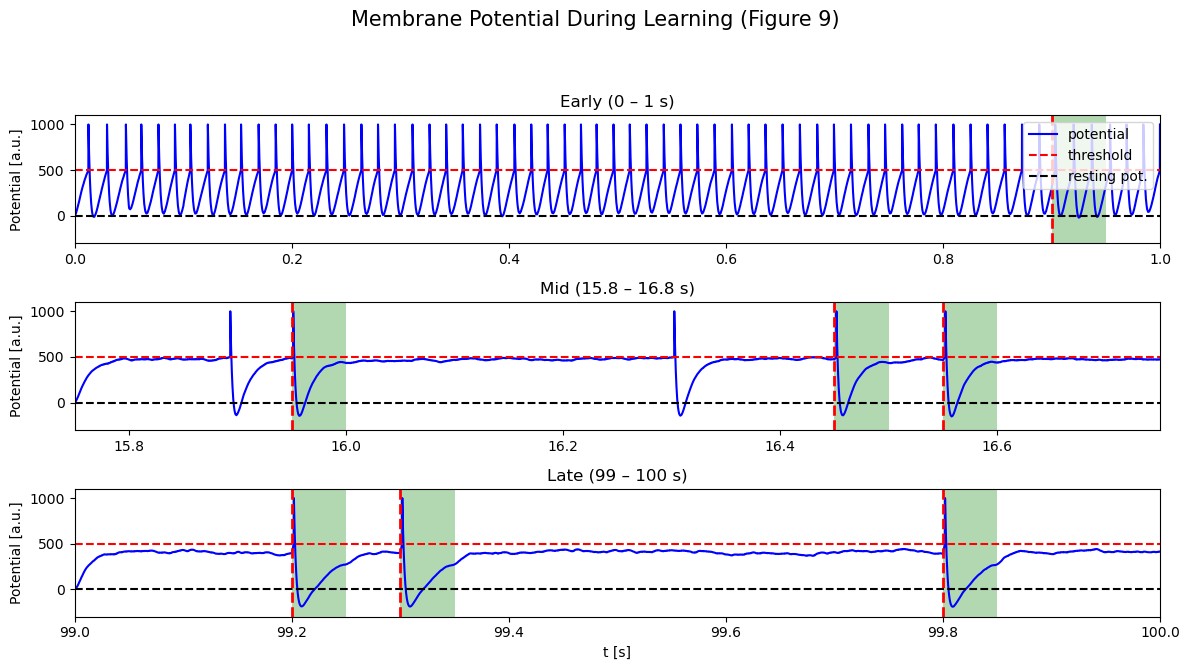

In [16]:
THETA = 500.0  # HG-LIF firing threshold (from config)

mid_start = max(find_t - 0.25, 0.0)
titles = [
    "Early (0 \u2013 1 s)",
    f"Mid ({mid_start:.1f} \u2013 {mid_start + 1:.1f} s)",
    f"Late ({TOTAL_SECONDS - 1} \u2013 {TOTAL_SECONDS} s)",
]
labels = ["early", "mid", "late"]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=False)
fig.suptitle("Membrane Potential During Learning (Figure 9)", fontsize=15)

pattern_onsets_s_plot = pattern_onsets * DT_SIM

for idx, (ax, title, label) in enumerate(zip(axes, titles, labels)):
    t_arr, v_arr = potentials[label]
    start, end = t_arr[0], t_arr[-1] + DT_SIM

    ax.plot(t_arr, v_arr, "b", label="potential")
    ax.axhline(y=THETA, color="r", linestyle="--", label="threshold")
    ax.axhline(y=0, color="k", linestyle="--", label="resting pot.")

    # Shade pattern windows
    onsets_in_window = pattern_onsets_s_plot[
        (pattern_onsets_s_plot >= start) & (pattern_onsets_s_plot < end)
    ]
    for onset in onsets_in_window:
        ax.axvline(onset, ls="--", c="r", linewidth=2)
        ax.axvspan(onset, onset + PATTERN_DURATION * DT_SIM,
                   facecolor="g", alpha=0.3)

    ax.set_xlim([start, end])
    ax.set_yticks([0, int(THETA), int(THETA * 2)])
    ax.set_ylim([-THETA * 0.6, THETA * 2.2])
    ax.set_ylabel("Potential [a.u.]")
    ax.set_title(title)
    if idx == 2:
        ax.set_xlabel("t [s]")

axes[0].legend(loc="upper right")
plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

## Summary

This tutorial demonstrated the core **SuperNeuroABM workflow**:

| Step | API Call | Purpose |
|------|----------|---------|
| 1 | `NeuromorphicModel(user_config=...)` | Create model with YAML config |
| 2 | `model.register_learning_rule(func, path)` | Register a custom STDP kernel; returns a numeric ID |
| 3 | `model.set_global_property_value("dt", ...)` | Set the simulation time step |
| 4 | `model.create_soma(breed, config_name)` | Create a neuron agent |
| 5 | `model.create_synapse(breed, pre, post, config_name, learning_rule, ...)` | Create a synapse agent with optional learning |
| 6 | `model.setup(use_gpu=True)` | One-time compilation (code gen + JIT) |
| 7 | `model.simulate(ticks=...)` | Run the simulation |
| 8 | `model.get_spike_times(soma_id)` | Retrieve output spike times |
| 9 | `model.get_agent_property_value(id, "hyperparameters")` | Read learned weights or other parameters |
| 10 | `model.get_internal_states_history(agent_id)` | Record membrane potential (with tracking enabled) |

Using this workflow, we replicated the key findings of **Masquelier et al. (2008)**: a single neuron with STDP learns to detect a spatiotemporal pattern in noisy background activity, achieving selective and temporally precise firing — entirely through unsupervised learning.